<h1>Trabalho 1 de ARQ - G13</h1>

<h1>Identificador automático de idioma</h1>
<p><b>Problema</b>: Dados um texto de entrada, é possível identificar em qual língua o texto está escrito?</p>
<p>
Entrada: "texto qualquer" <br />
Saída: português ou inglês ou francês ou italiano ou...
</p>
<p>&nbsp;</p>

<h2>O processo de Reconhecimento de Padrões</h2>
<p>O objetivo desse trabalho é demonstrar o processo de "construção de atributos" e como ele é fundamental para o <b>Reconhecimento de Padrões (RP)</b>.</p>

<p>Primeiro um conjunto de "amostras" previamente conhecido (classificado)</p>

In [ ]:
#
# amostras de texto em diferentes línguas
#
ingles = [
"Hello, how are you?",
"I love to read books.",
"The weather is nice today.",
"Where is the nearest restaurant?",
"What time is it?",
"I enjoy playing soccer.",
"Can you help me with this?",
"I'm going to the movies tonight.",
"This is a beautiful place.",
"I like listening to music.",
"Do you speak English?",
"What is your favorite color?",
"I'm learning to play the guitar.",
"Have a great day!",
"I need to buy some groceries.",
"Let's go for a walk.",
"How was your weekend?",
"I'm excited for the concert.",
"Could you pass me the salt, please?",
"I have a meeting at 2 PM.",
"I'm planning a vacation.",
"She sings beautifully.",
"The cat is sleeping.",
"I want to learn French.",
"I enjoy going to the beach.",
"Where can I find a taxi?",
"I'm sorry for the inconvenience.",
"I'm studying for my exams.",
"I like to cook dinner at home.",
"Do you have any recommendations for restaurants?",
]

espanhol = [
"Hola, ¿cómo estás?",
"Me encanta leer libros.",
"El clima está agradable hoy.",
"¿Dónde está el restaurante más cercano?",
"¿Qué hora es?",
"Voy al parque todos los días.",
"¿Puedes ayudarme con esto?",
"Me gustaría ir de vacaciones.",
"Este es mi libro favorito.",
"Me gusta bailar salsa.",
"¿Hablas español?",
"¿Cuál es tu comida favorita?",
"Estoy aprendiendo a tocar el piano.",
"¡Que tengas un buen día!",
"Necesito comprar algunas frutas.",
"Vamos a dar un paseo.",
"¿Cómo estuvo tu fin de semana?",
"Estoy emocionado por el concierto.",
"¿Me pasas la sal, por favor?",
"Tengo una reunión a las 2 PM.",
"Estoy planeando unas vacaciones.",
"Ella canta hermosamente.",
"El perro está jugando.",
"Quiero aprender italiano.",
"Disfruto ir a la playa.",
"¿Dónde puedo encontrar un taxi?",
"Lamento las molestias.",
"Estoy estudiando para mis exámenes.",
"Me gusta cocinar la cena en casa.",
"¿Tienes alguna recomendación de restaurantes?",
]

portugues = [
"Estou indo para o trabalho agora.",
"Adoro passar tempo com minha família.",
"Preciso comprar leite e pão.",
"Vamos ao cinema no sábado.",
"Gosto de praticar esportes ao ar livre.",
"O trânsito está terrível hoje.",
"A comida estava deliciosa!",
"Você já visitou o Rio de Janeiro?",
"Tenho uma reunião importante amanhã.",
"A festa começa às 20h.",
"Estou cansado depois de um longo dia de trabalho.",
"Vamos fazer um churrasco no final de semana.",
"O livro que estou lendo é muito interessante.",
"Estou aprendendo a cozinhar pratos novos.",
"Preciso fazer exercícios físicos regularmente.",
"Vou viajar para o exterior nas férias.",
"Você gosta de dançar?",
"Hoje é meu aniversário!",
"Gosto de ouvir música clássica.",
"Estou estudando para o vestibular.",
"Meu time de futebol favorito ganhou o jogo.",
"Quero aprender a tocar violão.",
"Vamos fazer uma viagem de carro.",
"O parque fica cheio aos finais de semana.",
"O filme que assisti ontem foi ótimo.",
"Preciso resolver esse problema o mais rápido possível.",
"Adoro explorar novos lugares.",
"Vou visitar meus avós no domingo.",
"Estou ansioso para as férias de verão.",
"Gosto de fazer caminhadas na natureza.",
"O restaurante tem uma vista incrível.",
"Vamos sair para jantar no sábado.",
]

A "amostras" de texto precisa ser "transformada" em <b>padrões</b>

<p>Um padrão é um conjunto de características, geralmente representado por um vetor e um conjunto de padrões no formato de tabela. Onde cada linha é um padrão e as colunas as características e, geralmente, na última coluna a <b>classe</b></p>

In [2]:
import random
RND_SEED = 13 # em homenagem ao grupo!

pre_padroes = []
for frase in ingles:
  pre_padroes.append( [frase, 'inglês'])

for frase in espanhol:
  pre_padroes.append( [frase, 'espanhol'])

for frase in portugues:
  pre_padroes.append( [frase, 'português'])

rng = random.Random(RND_SEED) # garantir a reprodutibilidade
rng.shuffle(pre_padroes)
print(pre_padroes)

[['I enjoy playing soccer.', 'inglês'], ['The weather is nice today.', 'inglês'], ['Vou viajar para o exterior nas férias.', 'português'], ['Gosto de praticar esportes ao ar livre.', 'português'], ['Preciso resolver esse problema o mais rápido possível.', 'português'], ["I'm sorry for the inconvenience.", 'inglês'], ['Estou indo para o trabalho agora.', 'português'], ['Estou estudando para o vestibular.', 'português'], ['Hello, how are you?', 'inglês'], ['Have a great day!', 'inglês'], ['El perro está jugando.', 'espanhol'], ['Where can I find a taxi?', 'inglês'], ['A festa começa às 20h.', 'português'], ['She sings beautifully.', 'inglês'], ['O livro que estou lendo é muito interessante.', 'português'], ['I enjoy going to the beach.', 'inglês'], ['Hola, ¿cómo estás?', 'espanhol'], ['Can you help me with this?', 'inglês'], ['Estoy planeando unas vacaciones.', 'espanhol'], ['Quiero aprender italiano.', 'espanhol'], ['Me gusta cocinar la cena en casa.', 'espanhol'], ['O trânsito está ter

O DataFrame do pandas facilita a visualização.

In [3]:
import pandas as pd
dados = pd.DataFrame(pre_padroes)
dados

,0,1
0,I enjoy playing soccer.,inglês
1,The weather is nice today.,inglês
2,Vou viajar para o exterior nas férias.,português
3,Gosto de praticar esportes ao ar livre.,português
4,Preciso resolver esse problema o mais rápido p...,português
...,...,...
87,I want to learn French.,inglês
88,Gosto de fazer caminhadas na natureza.,português
89,Vou visitar meus avós no domingo.,português
90,Me gustaría ir de vacaciones.,espanhol


<h1>Construção dos atributos</h1>
<p>Esse é o coração desse trabalho e que deverá ser desenvolvido por vocês. Pensem em como podemos "medir" cadas frase/sentença e extrair características que melhorem o resultado do processo de identificação.<p>
<p>Após a criação de cada novo atributo, execute as etapas seguintes e registre as métricas da matriz de confusão. Principalmente acurácia e a precisão.</p>

In [4]:
NGRAMS_pt = {

    # conectivos e palavras frequentes
    "com",
    
    # terminações típicas
    "ção",
    "oso",
    "osa",

    # padrões muito portugueses
    "nh",
    "lh",
    "ião",
    "ães",

    # verbos comuns
    "ava",
    "iam",
    "mos",
    "rei",

    # artigos/preposições frequentes
    " da",
    " do",
    " em",
    " os",
    " as",

    # padrões fonéticos
    "gua",
    "qua",

    # acentuação característica
    "não",
    "ões",
    "çã",

    # padrões exclusivos
    "ão",
    "ões",
    "ilh", 
    "anh"
}

NGRAMS_es = {

    # conectivos frequentes
    "con",
    "los",
    "las",

    # artigos/preposições
    " la",
    " el",
    " en",
    " un",
    "una",

    # terminações típicas
    "ción",
    "ido",
    "ida",

    # padrões verbais
    "aba",
    "ían",
    "ere",
    "ado",

    # padrões fortes do espanhol
    "ño",
    "ña",
    "ll",
    "ció",
    "ión",

    # palavras extremamente comuns
    "por",
    "del",
    "sus",
    "más",

    # padrões fonéticos
    "gue",
    "qui",

    # padrões exclusivos
    "ión", 
    "ique",
    "ilh",
    "aqu",
    "qué"

}

NGRAMS_en = {

    # palavras funcionais muito frequentes
    "the",
    "and",
    "ing",
    "ion",
    "ent",
    "for",
    "tha",
    "her",
    "ere",
    "hat",

    # verbos/terminações comuns
    "ing",
    "ted",
    "est",
    "ers",
    "ati",

    # conectivos frequentes
    "wit",
    "you",
    "not",
    "all",
    "thi",

    # padrões fonéticos típicos
    "th",
    "sh",
    "ch",
    "wh",

    # palavras muito frequentes
    "was",
    "are",
    "but",
    "one",
    "out",

    # sequências extremamente inglesas
    "ght",
    "ough",
    "ould",
    "ther",

    # padrões exclusivos
    "'m",
    "'s",
    "'t",
    "'re"
}

In [5]:
# a entrada é o vetor pre_padroes e a saída desse passo deverá ser "padrões"
import re

ACENTOS_CHAR = ['ã', 'õ', 'á', 'é', 'í', 'ó', 'ú', 'â', 'ê', 'ô', 'à']
CEDILHA_CHAR = ['ç']
N_TIL = ['ñ']
ESPANHOL_PONTUACAO = ['¿', '¡']
ESPANHOL_LETRA_N_TILDE = ['ñ'] #  é caracter léxico, ou seja, uma letra normal (não é pontuação)
#


def tamanhoMedioPalavras(texto):
  palavras = texto.split()
  #previne erro de divisão por zero
  if not palavras:
    return 0
  return round(sum(len(p) for p in palavras) / len(palavras),2)


def score_char_especial(texto, char_list):
  # conta a ocorrência de caracteres especiais
  texto = texto.lower() 
  return sum(texto.count(c) for c in char_list)
      
def score_ngrams(texto, ngrams):
    texto = texto.lower()
    #total = 0
    return sum(texto.count(ng) for ng in ngrams)
  

def extraiCaracteristicas(frase):
  # frase é um vetor [ 'texto', 'lingua' ]
  texto = frase[0]
  # acentos e símbolos latinos são mantidos, mas outros caracteres especiais são substituídos por espaço
  texto = re.sub(r'[^\w\s¿¡áéíóúãõçñíóúáéíó]', ' ', texto.lower())  # << MUDANÇA AQUI


  #print(texto)
  caracteristica1=tamanhoMedioPalavras(texto)
  caracteristica2=score_char_especial(texto, ACENTOS_CHAR) 
  caracteristica3=score_char_especial(texto, CEDILHA_CHAR)
  caracteristica4=score_char_especial(texto, N_TIL)
  caracteristica5=score_char_especial(texto, ESPANHOL_PONTUACAO)
  caracteristica6=score_char_especial(texto, ESPANHOL_LETRA_N_TILDE)
  caracteristica7=score_ngrams(texto, NGRAMS_pt)
  caracteristica8=score_ngrams(texto, NGRAMS_es)
  caracteristica9=score_ngrams(texto, NGRAMS_en)
  
 
  # acrescente as suas funcoes no vetor padrao
  padrao = [caracteristica1, 
            caracteristica2, 
            caracteristica3,
            caracteristica4,
            caracteristica5,
            caracteristica6,
            caracteristica7,
            caracteristica8,
            caracteristica9,
            frase[1] ]
  return padrao


def geraPadroes(frases):
  padroes = []
  for frase in frases:
    padrao = extraiCaracteristicas(frase)
    padroes.append(padrao)
  return padroes

# converte o formato [frase classe] em
# [caracteristica_1, caracteristica_2,... caracteristica n, classe]
padroes = geraPadroes(pre_padroes)

#
# apenas para visualizacao
#print(padroes)

dados = pd.DataFrame(padroes)
dados

,0,1,2,3,4,5,6,7,8,9
0,4.75,0,0,0,0,0,0,1,1,inglês
1,4.20,0,0,0,0,0,0,0,6,inglês
2,4.43,1,0,0,0,0,0,0,0,português
3,4.57,0,0,0,0,0,0,1,1,português
4,5.75,2,0,0,0,0,0,1,0,português
...,...,...,...,...,...,...,...,...,...,...
87,3.60,0,0,0,0,0,0,0,1,inglês
88,5.33,0,0,0,0,0,1,0,0,português
89,4.50,1,0,0,0,0,1,0,1,português
90,4.80,1,0,0,0,0,0,0,2,espanhol


<h1>Treinando o modelo com SVM</h1>

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

vet = np.array(padroes)
classes = vet[:,-1]            # Labels
caracteristicas = vet[:,0:-1]  # Features

# Split: 70% treino / 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    caracteristicas, 
    classes, 
    test_size=0.3, 
    stratify=classes,  # mantém proporção de classes
    random_state=RND_SEED
)

Como o SVM é sensível aos valores, fizemos um pipeline para padronizar e aplicamos um gridsearch para escolha dos melhores hiperparâmetros

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classificador', svm.SVC(random_state=RND_SEED))
])

# usa a parcela da base de dados fornecida para avaliar o modelo, mas com validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5, # 4 folds para treino e 1 para validar
    shuffle=True,
    random_state=RND_SEED
)

# Modelo SVM

parametros_busca_SVM = [
    {
        # SVM
        'classificador': [svm.SVC(random_state=RND_SEED)],
        'classificador__kernel': ['linear', 'rbf'],
        'classificador__C': [0.1, 1.0, 10.0, 50.0, 100.0],
        'classificador__gamma': ['scale', 'auto', 0.1, 1.0],
        'classificador__class_weight': [None, 'balanced'] # muda como o modelo aprende (penaliza mais erros em classes menos frequentes)
    }    
]

# Mantemos scoring='f1_macro' para forçar a IA a se importar com a nota do Espanhol 
# isto é, cada classe tem o mesmo peso
buscador_grid = GridSearchCV(
    estimator=pipeline, 
    param_grid=parametros_busca_SVM, 
    scoring='f1_macro', 
    cv=cv, 
    n_jobs=-1 # use todos os núcleos disponíveis para acelerar a busca
)

In [8]:
# Treinar o modelo e buscar os melhores hiperparâmetros
 
# Treinar APENAS em X_train, y_train
buscador_grid.fit(X_train, y_train)

# Retorna os dados do melhor modelo encontrado
melhor_config = buscador_grid.best_params_

In [9]:
from sklearn.metrics import accuracy_score

# Obtem a Acurácia do Treino
y_pred_treino = buscador_grid.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

# Obtem a Acurácia do Teste
y_pred = buscador_grid.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred)

best_score = buscador_grid.best_score_

print(f"Melhores parâmetros:\n {melhor_config}")
print("\nA Acurácia do treino foi: {:.2f}%".format(acc_treino * 100))
print("\nA Acurácia do teste foi: {:.2f}%".format(acc_teste * 100))
print("\nO score desse modelo foi : {:.2f}%".format(best_score * 100))


Melhores parâmetros:
 {'classificador': SVC(random_state=13), 'classificador__C': 100.0, 'classificador__class_weight': None, 'classificador__gamma': 0.1, 'classificador__kernel': 'rbf'}

A Acurácia do treino foi: 82.81%

A Acurácia do teste foi: 71.43%

O score desse modelo foi : 78.42%


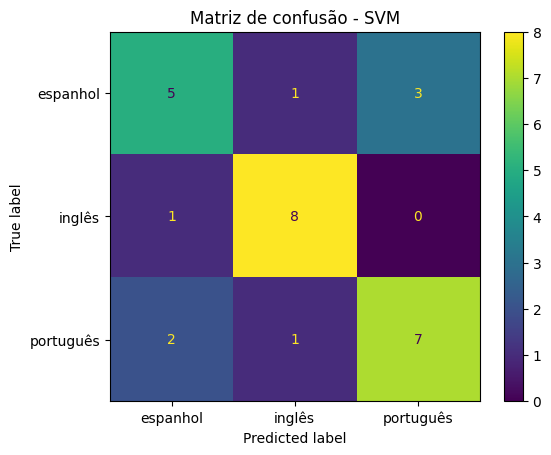

In [10]:
# Exibe a Matriz de confusão

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)
plt.title("Matriz de confusão - SVM")
plt.show()

# Na diagnal principal estão as predições corretas, e fora dela estão os erros.

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# recall do espanhol ou ingles estão muito sensíveis á partição do conjunto de treino/teste, 
# possivelmnte devido ao tamanho da base ser pequena

              precision    recall  f1-score   support

    espanhol       0.62      0.56      0.59         9
      inglês       0.80      0.89      0.84         9
   português       0.70      0.70      0.70        10

    accuracy                           0.71        28
   macro avg       0.71      0.71      0.71        28
weighted avg       0.71      0.71      0.71        28



<h1>Treinando o modelo com Random Forest</h1>

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest

parametros_busca_RF = [
    {
        # Random Forest
        'classificador': [RandomForestClassifier(random_state=RND_SEED)],
        'classificador__n_estimators': [50, 100, 200],
        'classificador__max_depth': [5, 10, 15],
        'classificador__class_weight': [None, 'balanced'] # muda como o modelo aprende (penaliza mais erros em classes menos frequentes)
    }
]

# Mantemos scoring='f1_macro' para forçar a IA a se importar com a nota do Espanhol 
# isto é, cada classe tem o mesmo peso
buscador_grid = GridSearchCV(
    estimator=pipeline, 
    param_grid=parametros_busca_RF, 
    scoring='f1_macro', 
    cv=cv, 
    n_jobs=-1 # use todos os núcleos disponíveis para acelerar a busca
)

# Treinar o modelo e buscar os melhores hiperparâmetros
 
# Treinar APENAS em X_train, y_train
buscador_grid.fit(X_train, y_train)

# Retorna os dados do melhor modelo encontrado
melhor_config = buscador_grid.best_params_

from sklearn.metrics import accuracy_score

# Obtem a Acurácia do Treino
y_pred_treino = buscador_grid.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

# Obtem a Acurácia do Teste
y_pred = buscador_grid.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred)

best_score = buscador_grid.best_score_

print(f"Melhores parâmetros:\n {melhor_config}")
print("\nA Acurácia do treino foi: {:.2f}%".format(acc_treino * 100))
print("\nA Acurácia do teste foi: {:.2f}%".format(acc_teste * 100))
print("\nO score desse modelo foi : {:.2f}%".format(best_score * 100))

Melhores parâmetros:
 {'classificador': RandomForestClassifier(random_state=13), 'classificador__class_weight': None, 'classificador__max_depth': 5, 'classificador__n_estimators': 200}

A Acurácia do treino foi: 93.75%

A Acurácia do teste foi: 85.71%

O score desse modelo foi : 76.55%


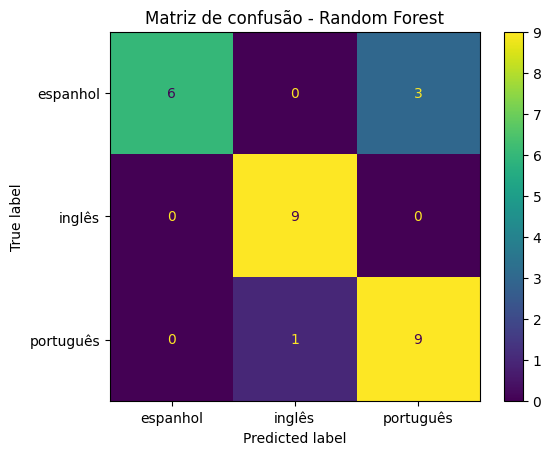

In [13]:
# Exibe a Matriz de confusão

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)
plt.title("Matriz de confusão - Random Forest")
plt.show()

# Na diagnal principal estão as predições corretas, e fora dela estão os erros.